In [8]:
%pip install --user --upgrade numpy scipy

     |████████████████████████████████| 19.5 MB 11.4 MB/s            
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import f_oneway
from matplotlib import pyplot as plt


files = {
    "n1": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/test/results.csv",
    "n2": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/test2/results.csv",

}
#CSV format:
#Matrix,Cores,Run,Iterations,IO_Time,SpMV_Time,SpMV_GFLOPS,Perf_Cycles,Perf_Instructions,Perf_CacheMisses,Perf_dTLBMisses
all_data = []
for name, path in files.items():
    df = pd.read_csv(path,index_col=False)
    df['Environment'] = name 
    all_data.append(df)

df = pd.concat(all_data, ignore_index=True)
df

FileNotFoundError: [Errno 2] No such file or directory: '/home/mengelsl/MA-bench-framework/outputs/spmv/v2/test.csv'

/tmp/ipykernel_953246/3020996161.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


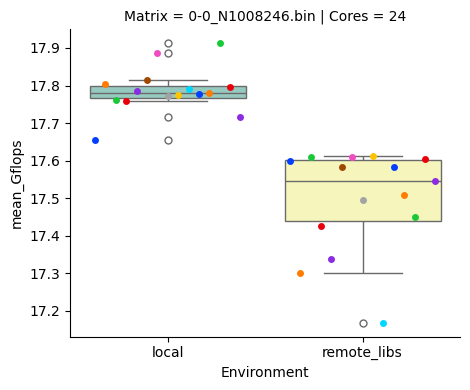

In [10]:
run_means_detailed = (
    df_iter
    .groupby(['Matrix', 'Cores', 'Environment', 'Run'])['Gflops']
    .mean()
    .reset_index(name='mean_Gflops')
)

g = sns.catplot(
    data=run_means_detailed, 
    x='Environment', 
    y='mean_Gflops', 
    col='Cores', 
    row='Matrix', 
    kind='box',    
    palette='Set3',
    height=4, 
    aspect=1.2,
    sharey=False  
)

g.map_dataframe(
    sns.swarmplot, 
    x='Environment', 
    y='mean_Gflops', 
    hue='Run', 
    palette='bright',
    dodge=True
)

<Axes: xlabel='Iteration', ylabel='Gflops'>

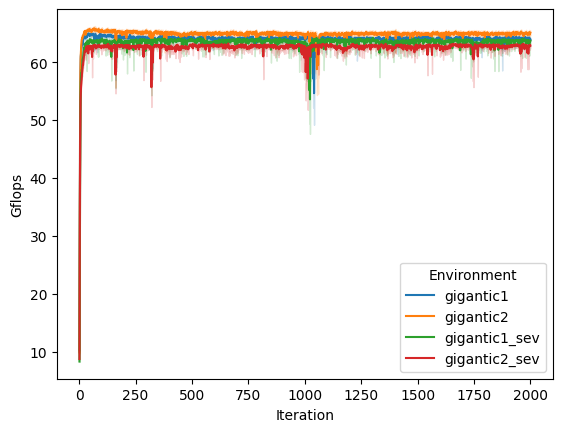

In [18]:
sns.lineplot(data=df_iter[(df_iter["Cores"]== 72) & (df_iter["Matrix"]== '0-0_N1008246.bin')], x='Iteration', y='Gflops', hue='Environment')